In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

In [8]:
!pip install pyfglt networkx matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 3.5 MB/s eta 0:00:00


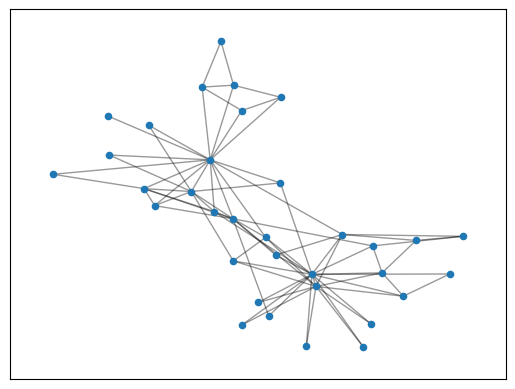

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

seed = 42
G = nx.karate_club_graph()
pos = nx.spring_layout(G, seed=seed)
fig, ax = plt.subplots()
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=20)
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4)
plt.show()

In [4]:
import pyfglt.fglt as fg
F = fg.compute(G)
F.head()

,[0] vertex (==1),[1] degree,[2] 2-path,[3] bifork,[4] 3-cycle,"[5] 3-path, end","[6] 3-path, interior","[7] claw, leaf","[8] claw, root","[9] paw, handle","[10] paw, base","[11] paw, center",[12] 4-cycle,"[13] diamond, off-cord","[14] diamond, on-cord",[15] 4-clique
Node id (0-based),,,,,,,,,,,,,,,,
0,1,16,17,102,18,81,197,13,352,6,34,171,10,2,30,7
1,1,9,19,24,12,73,56,33,32,8,80,27,6,2,18,7
2,1,10,34,34,11,72,179,84,54,17,75,51,20,6,8,7
3,1,6,20,5,10,49,11,56,1,5,81,5,0,4,7,7
4,1,3,16,1,2,17,1,64,0,15,25,0,1,2,1,0


In [5]:
F=np.array(F)
for node in sorted(G.nodes()):
        vec = F[node]
        print(f"  Node {node:2d}: [{vec[1]:2d}, {vec[2]:2d}, {vec[4]:2d}] "
              f"(Degree: {vec[1]}, Paths: {vec[2]}, Triangles: {vec[4]})")

  Node  0: [16, 17, 18] (Degree: 16, Paths: 17, Triangles: 18)
  Node  1: [ 9, 19, 12] (Degree: 9, Paths: 19, Triangles: 12)
  Node  2: [10, 34, 11] (Degree: 10, Paths: 34, Triangles: 11)
  Node  3: [ 6, 20, 10] (Degree: 6, Paths: 20, Triangles: 10)
  Node  4: [ 3, 16,  2] (Degree: 3, Paths: 16, Triangles: 2)
  Node  5: [ 4, 15,  3] (Degree: 4, Paths: 15, Triangles: 3)
  Node  6: [ 4, 15,  3] (Degree: 4, Paths: 15, Triangles: 3)
  Node  7: [ 4, 25,  6] (Degree: 4, Paths: 25, Triangles: 6)
  Node  8: [ 5, 44,  5] (Degree: 5, Paths: 44, Triangles: 5)
  Node  9: [ 2, 25,  0] (Degree: 2, Paths: 25, Triangles: 0)
  Node 10: [ 3, 16,  2] (Degree: 3, Paths: 16, Triangles: 2)
  Node 11: [ 1, 15,  0] (Degree: 1, Paths: 15, Triangles: 0)
  Node 12: [ 2, 18,  1] (Degree: 2, Paths: 18, Triangles: 1)
  Node 13: [ 5, 41,  6] (Degree: 5, Paths: 41, Triangles: 6)
  Node 14: [ 2, 25,  1] (Degree: 2, Paths: 25, Triangles: 1)
  Node 15: [ 2, 25,  1] (Degree: 2, Paths: 25, Triangles: 1)
  Node 16: [ 2,  4

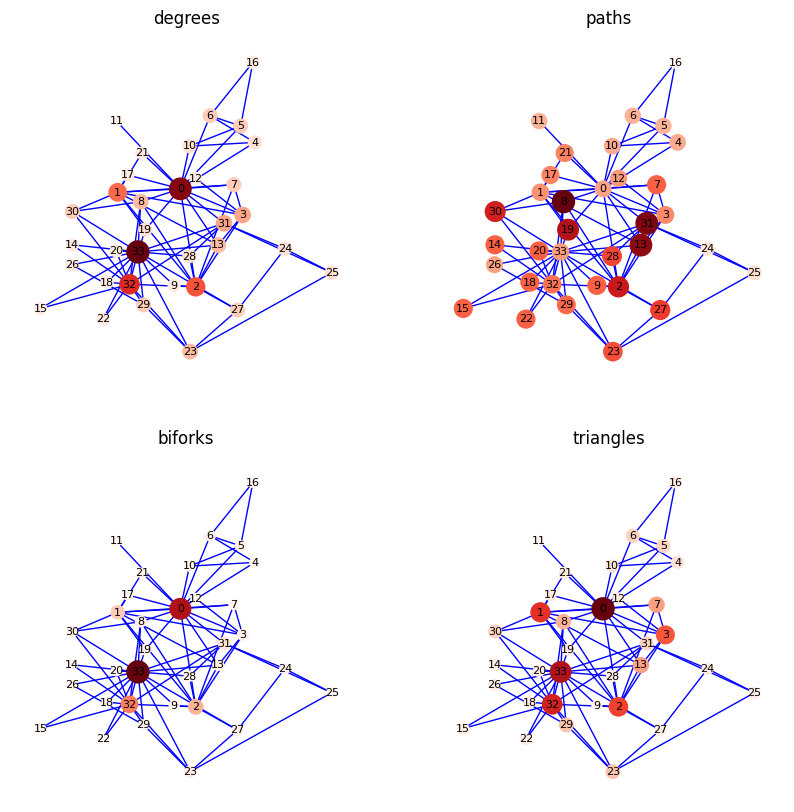

In [6]:
pos = nx.kamada_kawai_layout(G)
# norm_vectors = normalize_vectors(graphlet_vectors)

degrees = [F[node,1] for node in G.nodes()]
paths = [F[node,2] for node in G.nodes()]
biforks = [F[node,3] for node in G.nodes()]
triangles = [F[node,4] for node in G.nodes()]
labels=['degrees','paths','biforks','triangles']
# Create subplots
plt.figure(figsize=(10,10))
for i,glt in enumerate((degrees,paths,biforks,triangles)):
 plt.subplot(2, 2, i+1)
 plt.title(labels[i])
 nx.draw(G, pos,
            node_color=glt,
            cmap=plt.cm.Reds,
            node_size=[50 + (200*v)/np.array(glt).max() for v in glt],
            with_labels=True,
            font_size=8,
            edge_color='blue')

(34, 2)


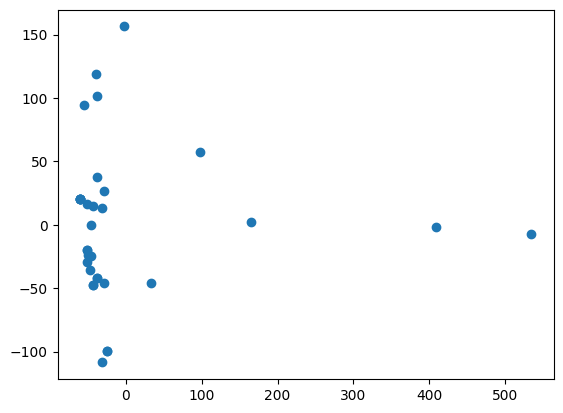

In [7]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X=pca.fit_transform(F)
print(X.shape)
plt.scatter(X[:,0],X[:,1])


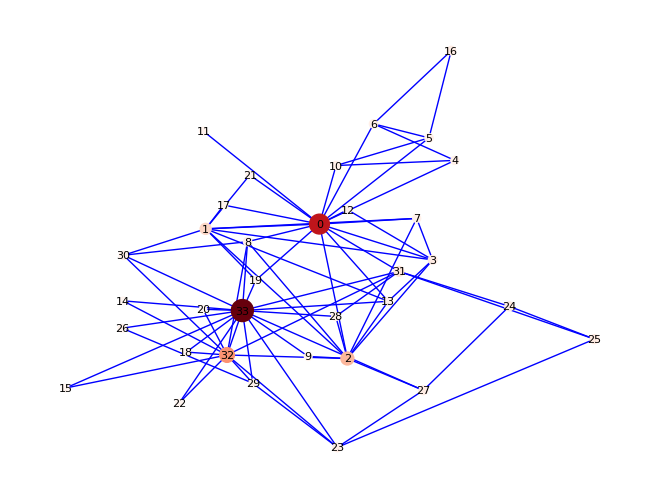

In [8]:
 nx.draw(G, pos,
            node_color=X[:,0],
            cmap=plt.cm.Reds,
            node_size=[50 + (200*v)/X[:,0].max() for v in list(X[:,0])],
            with_labels=True,
            font_size=8,
            edge_color='blue')

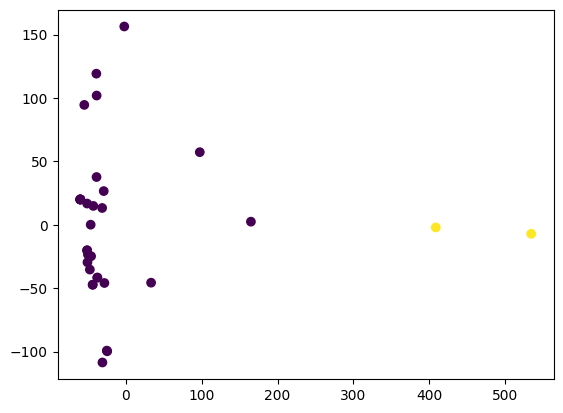

In [9]:
from sklearn.mixture import GaussianMixture
clf=GaussianMixture(n_components=2)
c=clf.fit_predict(X)
plt.scatter(X[:,0],X[:,1],c=c)

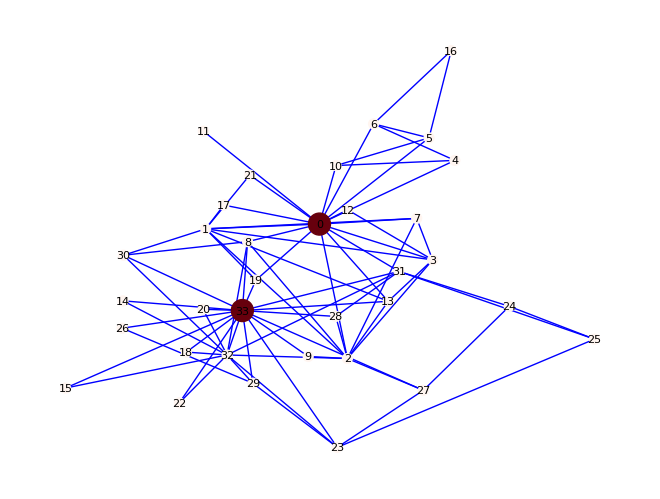

In [10]:
 nx.draw(G, pos,
            node_color=c,
            cmap=plt.cm.Reds,
            node_size=[50 + (200*v) for v in list(c)],
            with_labels=True,
            font_size=8,
            edge_color='blue')